<a href="https://colab.research.google.com/github/Prashant230531/AI_FinalYear/blob/worksheet/Workshop5_PrashantSharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 Worksheet - 5: CNN Image Classification
## End-to-End Image Classifier for Amazon Fruits

**CNN Implemented using Keras.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Required Libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(123)
tf.random.set_seed(123)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check GPU availability
print(f"\nGPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
Keras version: 3.13.2

GPU Available: []


## Task 1: Data Understanding and Visualization

In [3]:
# Define the path to your dataset in Google Drive
base_dir = '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Verify paths exist
print("Checking dataset paths...")
print(f"Base directory exists: {os.path.exists(base_dir)}")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

if not os.path.exists(train_dir):
    print("\n⚠ ERROR: Train directory not found!")
    print(f"Expected path: {train_dir}")
    print("\nPlease verify your Google Drive folder structure.")
else:
    print("\n✓ All paths verified successfully!")

Checking dataset paths...
Base directory exists: True
Train directory exists: True
Test directory exists: True

✓ All paths verified successfully!


### 1.2 Explore Dataset Structure

In [4]:
# Get list of class directories
class_names = sorted([d for d in os.listdir(train_dir)
                      if os.path.isdir(os.path.join(train_dir, d))])

print(f"Found {len(class_names)} classes:")
print("="*50)
for i, class_name in enumerate(class_names, 1):
    class_path = os.path.join(train_dir, class_name)
    num_images = len([f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"{i}. {class_name:12s} - {num_images:4d} images")
print("="*50)

Found 6 classes:
1. acai         -   15 images
2. cupuacu      -   15 images
3. graviola     -   15 images
4. guarana      -   15 images
5. pupunha      -   15 images
6. tucuma       -   15 images


# Visualize one random image from each class

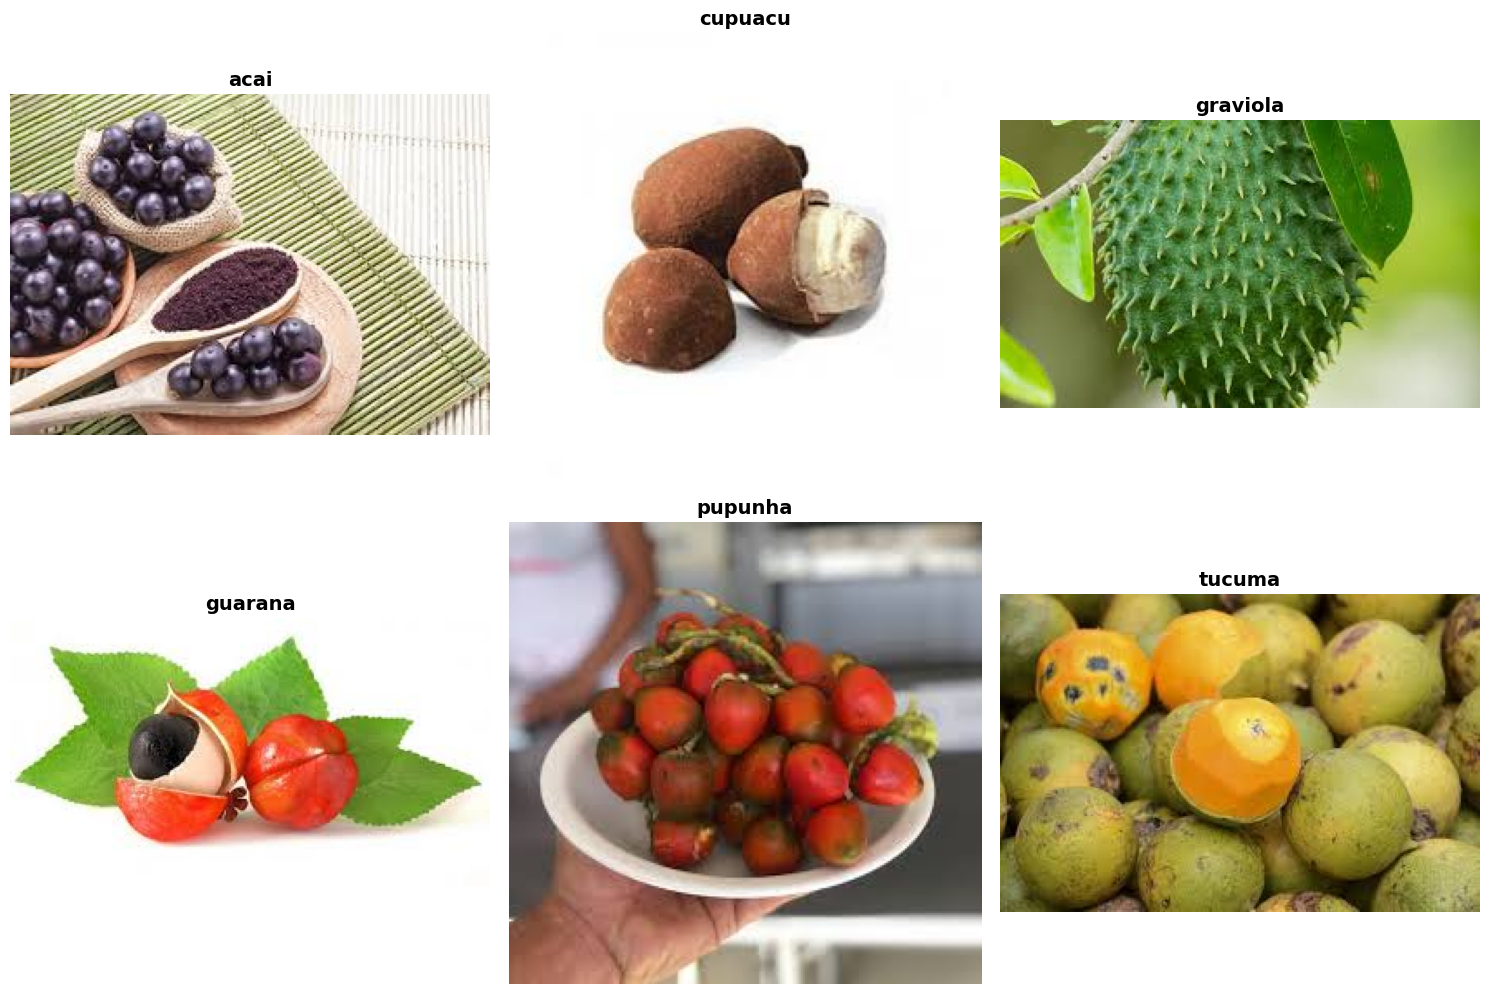


### Observations:
1. The dataset contains 6 different Amazon fruit classes
2. Images show diverse fruit types with varying colors and textures
3. Image sizes and aspect ratios may vary across the dataset
4. Some fruits have distinctive visual features (color, shape, texture)


In [5]:
num_classes = len(class_names)
cols = 3
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten() if num_classes > 1 else [axes]

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)

    # Get all image files in the class directory
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:
        # Select one random image
        random_image = random.choice(image_files)
        image_path = os.path.join(class_path, random_image)

        # Load and display the image
        img = Image.open(image_path)
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=14, fontweight='bold')
        axes[idx].axis('off')

# Hide extra subplots
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n### Observations:")
print(f"1. The dataset contains {num_classes} different Amazon fruit classes")
print("2. Images show diverse fruit types with varying colors and textures")
print("3. Image sizes and aspect ratios may vary across the dataset")
print("4. Some fruits have distinctive visual features (color, shape, texture)")

Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

In [6]:
def check_and_remove_corrupted_images(directory):
    """
    Check for corrupted images in the dataset and remove them.

    Args:
        directory: Path to the directory containing class subdirectories

    Returns:
        List of corrupted image paths that were removed
    """
    corrupted_images = []

    # Iterate through each class subdirectory
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        # Check each image in the class directory
        for image_file in os.listdir(class_path):
            if not image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                continue

            image_path = os.path.join(class_path, image_file)

            try:
                # Try to open the image
                with Image.open(image_path) as img:
                    # Verify the image by loading it
                    img.verify()

                # Reopen for additional check (verify() closes the file)
                with Image.open(image_path) as img:
                    img.load()

            except (IOError, SyntaxError, OSError) as e:
                # Image is corrupted
                print(f"Removed corrupted image: {image_path}")
                corrupted_images.append(image_path)

                # Remove the corrupted image
                os.remove(image_path)

    return corrupted_images

# Check for corrupted images in training directory
print("Checking for corrupted images in training directory...")
corrupted_train = check_and_remove_corrupted_images(train_dir)

# Check test directory if it exists
if os.path.exists(test_dir):
    print("\nChecking for corrupted images in test directory...")
    corrupted_test = check_and_remove_corrupted_images(test_dir)
    total_corrupted = len(corrupted_train) + len(corrupted_test)
else:
    total_corrupted = len(corrupted_train)

if total_corrupted == 0:
    print("\n✓ No corrupted images found.")
else:
    print(f"\n✗ Found and removed {total_corrupted} corrupted images.")

Checking for corrupted images in training directory...

Checking for corrupted images in test directory...

✓ No corrupted images found.


##Task 2: Loading and Preprocessing Image Data in keras:

This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.

In [7]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 16  # As specified in Task 4
validation_split = 0.2  # 80% training, 20% validation

# Get number of classes
num_classes = len(class_names)

print(f"Image dimensions: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")
print(f"Validation split: {validation_split * 100}%")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Image dimensions: 128 x 128
Batch size: 16
Validation split: 20.0%
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Creating a preprocessing layer for normalization

In [8]:
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0, 1]

# Create training dataset
print("Creating training dataset...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset
print("Creating validation dataset...")
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Create test dataset (if test directory exists)
if os.path.exists(test_dir):
    print("Creating test dataset...")
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(img_height, img_width),
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False
    )

    # Apply normalization to test dataset
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
    print("✓ Test dataset created successfully")
else:
    print("⚠ Test directory not found. Using validation set for testing.")
    test_ds = val_ds

# Optimize performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n✓ All datasets created and preprocessed successfully!")

Creating training dataset...
Found 90 files belonging to 6 classes.
Using 72 files for training.
Creating validation dataset...
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Creating test dataset...
Found 30 files belonging to 6 classes.
✓ Test dataset created successfully

✓ All datasets created and preprocessed successfully!


In [9]:
class_names

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

VISUALIZE DATA

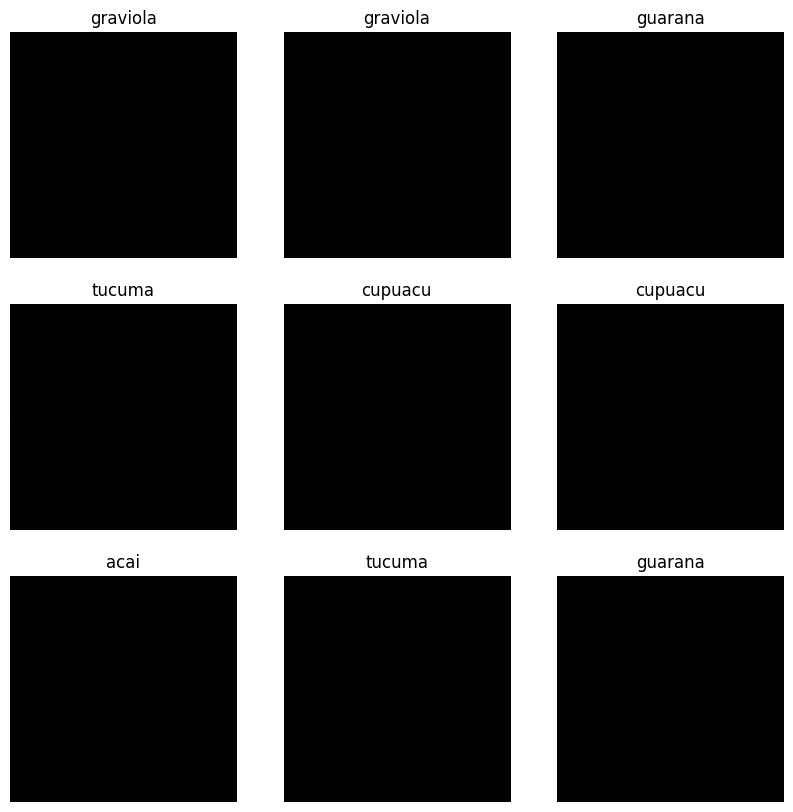

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 814ms/step - accuracy: 0.1389 - loss: 2.6391 - val_accuracy: 0.7778 - val_loss: 1.4968
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3056 - loss: 1.7950 - val_accuracy: 0.0556 - val_loss: 1.7714
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 582ms/step - accuracy: 0.2639 - loss: 1.6263 - val_accuracy: 0.7778 - val_loss: 1.5002
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 581ms/step - accuracy: 0.5556 - loss: 1.4037 - val_accuracy: 0.7222 - val_loss: 1.2282
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 593ms/step - accuracy: 0.6528 - loss: 1.1736 - val_accuracy: 0.7778 - val_loss: 1.0391
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 595ms/step - accuracy: 0.7083 - loss: 0.8984 - val_accuracy: 0.6667 - val_loss: 1.0487
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8472 - loss: 0.5844 - val_accuracy: 0.8333 - val

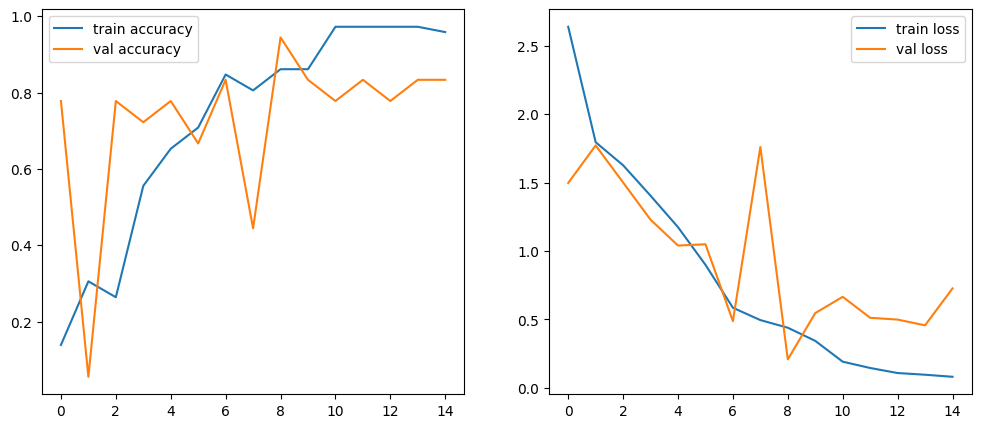

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

train_dir =  '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train'
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = layers.Rescaling(1./255)

# Load original datasets first
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Get class names BEFORE mapping/prefetching
class_names = raw_train_ds.class_names
num_classes = len(class_names)

# Apply normalization
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds = raw_val_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

train_dir =  '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train'
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = layers.Rescaling(1./255)

raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds = raw_val_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

model = models.Sequential([
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 615ms/step - accuracy: 0.1528 - loss: 2.1976 - val_accuracy: 0.0000e+00 - val_loss: 1.6252
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 383ms/step - accuracy: 0.3056 - loss: 1.7573 - val_accuracy: 0.2778 - val_loss: 1.5182
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step - accuracy: 0.4167 - loss: 1.6482 - val_accuracy: 0.4444 - val_loss: 1.5647
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 385ms/step - accuracy: 0.4583 - loss: 1.4463 - val_accuracy: 0.7222 - val_loss: 1.1572
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step - accuracy: 0.5417 - loss: 1.2102 - val_accuracy: 0.6667 - val_loss: 1.1602
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 388ms/step - accuracy: 0.7778 - loss: 0.8979 - val_accuracy: 0.8333 - val_loss: 0.8027
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 654ms/step - accuracy: 0.8056 - loss: 0.6831 - val_accuracy: 0.

In [15]:
# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
     '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train',
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
     '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train',
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

# Get number of classes BEFORE mapping
num_classes = len(train_ds.class_names)

# Normalize and prefetch
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ----------------------------
# Dataset paths
# ----------------------------
train_dir =  '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train'
val_dir   =  '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/test'

# ----------------------------
# Load datasets
# ----------------------------
batch_size = 16
img_height = 128
img_width  = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ----------------------------
# Model definition
# ----------------------------
num_classes = len(train_ds.class_names)  # automatically detect number of classes

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),  # input layer
    layers.Rescaling(1./255),                        # normalize images
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# ----------------------------
# Compile model
# ----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# Callbacks
# ----------------------------
checkpoint_cb = ModelCheckpoint(
    "best_model.keras", save_best_only=True
)

earlystop_cb = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

# ----------------------------
# Train the model
# ----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.1333 - loss: 2.0479 - val_accuracy: 0.1667 - val_loss: 1.7570
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 354ms/step - accuracy: 0.2556 - loss: 1.7465 - val_accuracy: 0.2333 - val_loss: 1.7220
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.3444 - loss: 1.6492 - val_accuracy: 0.3000 - val_loss: 1.5355
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 352ms/step - accuracy: 0.3889 - loss: 1.4120 - val_accuracy: 0.3667 - val_loss: 1.3309
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 459ms/step - accuracy: 0.4556 - loss: 1.2076 - val_accuracy: 0.5333 - val_loss: 1.1872
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 517ms/step - accuracy: 0.7222 - loss: 1.0225 - val_accuracy: 0.5000 - val_loss: 1.2206
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step - accuracy: 0.7333 - loss: 0.7455 - val_accuracy: 0.6667 - val_loss: 1.0272
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━

In [17]:
import tensorflow as tf

# Paths to your folders
train_dir =  '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train'
val_dir   =  '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/test'

# Image dimensions
img_height = 128
img_width  = 128
batch_size = 16

# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7333 - loss: 0.8598
Test Loss: 0.8598
Test Accuracy: 0.7333


In [18]:
import tensorflow as tf

# --- Assuming your model is already trained and test_ds is loaded ---

# 1️⃣ Save the model to an HDF5 (.h5) file
model.save("my_trained_model.h5")
print("Model saved successfully!")

# 2️⃣ Load the saved model
loaded_model = tf.keras.models.load_model("my_trained_model.h5")
print("Model loaded successfully!")

# 3️⃣ Re-evaluate on the test dataset
test_loss, test_accuracy = loaded_model.evaluate(test_ds)
print(f"Test Loss (loaded model): {test_loss:.4f}")
print(f"Test Accuracy (loaded model): {test_accuracy:.4f}")

Model saved successfully!
Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7333 - loss: 0.8598
Test Loss (loaded model): 0.8598
Test Accuracy (loaded model): 0.7333


In [19]:
import numpy as np
from sklearn.metrics import classification_report

# 1️⃣ Get class names (ensure you have them from training dataset)
class_names = train_ds.class_names  # or manually list them if needed

# 2️⃣ Make predictions on the test set
y_pred_probs = loaded_model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # convert probabilities to class labels

# 3️⃣ Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 4️⃣ Generate Classification Report
report = classification_report(y_true, y_pred_labels, target_names=class_names)
print("Classification Report:\n")
print(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 932ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.12      0.20      0.15         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.03        30
   macro avg       0.02      0.03      0.03        30
weighted avg       0.02      0.03      0.03        30

